<a href="https://colab.research.google.com/github/Sanika13112/Autoencoder_vs_VAE_Image_Reconstruction_and_Generation/blob/main/Sanika_Mane_Autoencoder_vs_VAE_Image_Reconstruction_and_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Autoencoder vs. Variational Autoencoder (VAE)
### Comprehensive Study on Image Reconstruction, Latent Representations, and Generative Modeling

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)

---

##  Executive Summary & Theoretical Context
In deep representation learning, **Autoencoders (AE)** and **Variational Autoencoders (VAE)** represent two fundamentally contrasting paradigms for compression, dimensionality reduction, and generative modeling:

1. **Deterministic Autoencoder (AE)**:
   - Maps an input $x$ deterministically to an unconstrained bottleneck vector $z = f_\theta(x)$ and reconstructs $\hat{x} = g_\phi(z)$.
   - Latent space is **unregularized**: the encoder places representations into arbitrary, disconnected clusters separated by large empty voids ("dead zones").
   - **Superb for deterministic compression and denoising**, but **fundamentally incapable of principled random image generation**.

2. **Probabilistic Variational Autoencoder (VAE)**:
   - Originates from variational Bayesian inference and directed graphical models ($p_\theta(x, z) = p_\theta(x|z)p(z)$).
   - Constrains the approximate posterior $q_\phi(z|x)$ toward an isotropic standard normal prior $\mathcal{N}(0, I)$ via the **Evidence Lower Bound (ELBO)** and the **Reparameterization Trick**.
   - Latent space is **continuous, smooth, and complete**, enabling **random generation** ($z \sim \mathcal{N}(0, I)$) and **meaningful semantic interpolation**.

---

## Notebook Roadmap
1. **Mathematical Derivations**: Loss functions, closed-form KL divergence, and the reparameterization trick.
2. **Environment & Pipeline Setup**: Reproducibility seeds, PyTorch GPU acceleration, and MNIST data pipeline.
3. **Model Architectures**: Matched Convolutional Autoencoder (ConvAE) and Convolutional VAE (ConvVAE).
4. **Training & ELBO Dynamics**: Training loops with loss decomposition (Reconstruction vs. KL divergence).
5. **Rigorous Empirical Comparison**:
   - **Experiment 1: Reconstruction Fidelity**: Side-by-side visual comparisons, residual error heatmaps, MSE, PSNR, and SSIM.
   - **Experiment 2: Random Image Generation**: Prior sampling $z \sim \mathcal{N}(0, I)$ through both decoders.
   - **Experiment 3: Latent Space Geometry**: 2D scatter plots of digit clusters revealing distribution smoothness vs. gaps.
   - **Experiment 4: 2D Generative Manifold Walk**: Comprehensive coordinate grid exploration across $[-3, 3] \times [-3, 3]$.
   - **Experiment 5: Semantic Latent Interpolation**: Trajectory morphing between digits in latent space.
6. **Key Insights & Comparative Decision Matrix**.


---
##  Mathematical Foundations

### 1. Classical Autoencoder (AE)
Given an observed data point $x \in \mathbb{R}^D$, an encoder parameterized by $\theta$ maps $x$ to a deterministic bottleneck $z \in \mathbb{R}^d$ ($d \ll D$):
$$z = f_\theta(x)$$
A decoder parameterized by $\phi$ reconstructs the input:
$$\hat{x} = g_\phi(z) = g_\phi(f_\theta(x))$$
The empirical objective minimizes reconstruction loss:
$$\mathcal{L}_{\text{AE}}(\theta, \phi) = \frac{1}{N}\sum_{i=1}^N \mathcal{L}_{\text{recon}}(x^{(i)}, \hat{x}^{(i)})$$

---

### 2. Variational Autoencoder (VAE)
The VAE treats $z$ as a continuous latent random variable governed by a prior distribution $p(z) = \mathcal{N}(0, I)$. The true posterior $p_\theta(z|x) = \frac{p_\theta(x|z)p(z)}{p(x)}$ is intractable due to the integral $p(x) = \int p_\theta(x|z)p(z)dz$.

We approximate $p_\theta(z|x)$ with a tractable variational family $q_\phi(z|x) = \mathcal{N}(\mu_\phi(x), \text{diag}(\sigma_\phi^2(x)))$.

Maximizing the marginal log-likelihood $\log p_\theta(x)$ is achieved by maximizing the **Evidence Lower Bound (ELBO)**:
$$\log p_\theta(x) \ge \text{ELBO}(\theta, \phi; x) = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - D_{\text{KL}}(q_\phi(z|x) \parallel p(z))$$

The negative ELBO training loss is:
$$\mathcal{L}_{\text{VAE}}(\theta, \phi) = \underbrace{-\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{Reconstruction Loss (Fidelity)}} + \beta \cdot \underbrace{D_{\text{KL}}(q_\phi(z|x) \parallel \mathcal{N}(0, I))}_{\text{Regularization Loss (Latent Smoothness)}}$$

#### Closed-Form KL Divergence for Diagonal Gaussians:
$$D_{\text{KL}}(q_\phi(z|x) \parallel \mathcal{N}(0, I)) = -\frac{1}{2}\sum_{j=1}^d \left( 1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2 \right)$$

#### The Reparameterization Trick:
Direct sampling $z \sim q_\phi(z|x)$ prevents backpropagation because sampling operations have zero gradients with respect to $\phi$. The reparameterization trick transforms the stochastic node into a deterministic operation conditioned on auxiliary noise $\epsilon$:
$$z = \mu_\phi(x) + \sigma_\phi(x) \odot \epsilon, \quad \text{where } \epsilon \sim \mathcal{N}(0, I)$$
This enables gradients to propagate cleanly via pathwise derivative estimation:
$$\nabla_\phi \mathbb{E}_{q_\phi(z|x)}[f(z)] = \mathbb{E}_{\epsilon \sim \mathcal{N}(0, I)} \left[ \nabla_z f(z) \cdot \nabla_\phi z \right]$$


In [1]:
# ==============================================================================
# Cell 1: Environment Setup, Dependencies & Reproducibility Seeds
# ==============================================================================
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

# Fix all random seeds for deterministic execution across runs
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Hardware acceleration verification
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[*] Execution Device: {device}")
if torch.cuda.is_available():
    print(f"[*] GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"[*] GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("[!] GPU unavailable; running on CPU.")


[*] Execution Device: cuda
[*] GPU Model: Tesla T4
[*] GPU Memory: 15.64 GB


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 472kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.50MB/s]

[*] Training dataset: 60,000 samples (469 batches)
[*] Testing dataset:  10,000 samples (79 batches)


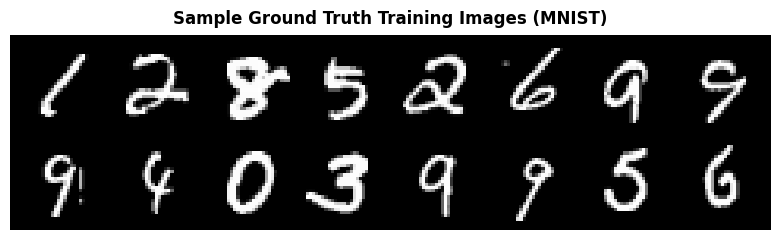

In [2]:
# ==============================================================================
# Cell 2: Dataset Configuration & DataLoaders
# ==============================================================================
# @title Hyperparameter Configuration { run: "auto" }
BATCH_SIZE = 128        # @param {type:"integer"}
LATENT_DIM = 2          # @param {type:"integer"} - 2D allows direct manifold visualization without t-SNE
LEARNING_RATE = 1e-3    # @param {type:"number"}
NUM_EPOCHS = 15         # @param {type:"integer"}
BETA = 1.0              # @param {type:"number"} - Weight for KL divergence (Beta-VAE)

# Transform: Map pixel values to [0.0, 1.0] for Bernoulli likelihood modeling
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Download dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

num_workers = 2 if os.name != 'nt' else 0
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)

print(f"[*] Training dataset: {len(train_dataset):,} samples ({len(train_loader)} batches)")
print(f"[*] Testing dataset:  {len(test_dataset):,} samples ({len(test_loader)} batches)")

# Preview sample ground truth images
preview_imgs, preview_labels = next(iter(train_loader))
grid = make_grid(preview_imgs[:16], nrow=8, padding=2)

plt.figure(figsize=(10, 2.5))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.title("Sample Ground Truth Training Images (MNIST)", fontsize=12, fontweight='bold', pad=8)
plt.axis('off')
plt.tight_layout()
plt.show()


In [3]:
# ==============================================================================
# Cell 3: Convolutional Autoencoder (ConvAE)
# ==============================================================================
class ConvEncoder(nn.Module):
    # Shared convolutional encoder backbone:
    # Input:  (B, 1, 28, 28)
    # Conv1:  (B, 32, 14, 14)
    # Conv2:  (B, 64, 7, 7)
    # Dense:  (B, 128)
    def __init__(self):
        super(ConvEncoder, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.fc = nn.Linear(64 * 7 * 7, 128)

    def forward(self, x):
        x = F.leaky_relu(self.bn1(self.conv1(x)), negative_slope=0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), negative_slope=0.2)
        x = x.view(x.size(0), -1)
        x = F.leaky_relu(self.fc(x), negative_slope=0.2)
        return x

class ConvDecoder(nn.Module):
    # Shared convolutional decoder backbone:
    # Input:    (B, latent_dim)
    # Dense1:   (B, 128)
    # Dense2:   (B, 64 * 7 * 7)
    # Deconv1:  (B, 32, 14, 14)
    # Deconv2:  (B, 1, 28, 28)
    def __init__(self, latent_dim):
        super(ConvDecoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim, 128)
        self.fc2 = nn.Linear(128, 64 * 7 * 7)
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.deconv2 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, z):
        x = F.leaky_relu(self.fc1(z), negative_slope=0.2)
        x = F.leaky_relu(self.fc2(x), negative_slope=0.2)
        x = x.view(x.size(0), 64, 7, 7)
        x = F.leaky_relu(self.bn1(self.deconv1(x)), negative_slope=0.2)
        x = self.sigmoid(self.deconv2(x))
        return x

class Autoencoder(nn.Module):
    # Deterministic Autoencoder with direct projection to latent bottleneck.
    def __init__(self, latent_dim=2):
        super(Autoencoder, self).__init__()
        self.encoder_backbone = ConvEncoder()
        self.fc_latent = nn.Linear(128, latent_dim)
        self.decoder = ConvDecoder(latent_dim)

    def encode(self, x):
        h = self.encoder_backbone(x)
        return self.fc_latent(h)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        recon_x = self.decode(z)
        return recon_x, z

ae_model = Autoencoder(latent_dim=LATENT_DIM).to(device)
ae_param_count = sum(p.numel() for p in ae_model.parameters())
print(f"[*] Autoencoder successfully built! Total Trainable Parameters: {ae_param_count:,}")


[*] Autoencoder successfully built! Total Trainable Parameters: 844,547


In [4]:
# ==============================================================================
# Cell 4: Convolutional Variational Autoencoder (ConvVAE)
# ==============================================================================
class VariationalAutoencoder(nn.Module):
    # Variational Autoencoder with twin heads (mu, logvar) and Reparameterization Trick.
    # Capacity matches ConvAE identically for fair benchmarking.
    def __init__(self, latent_dim=2):
        super(VariationalAutoencoder, self).__init__()
        self.latent_dim = latent_dim
        self.encoder_backbone = ConvEncoder()

        # Dual linear heads for variational Gaussian parameters
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # Matched decoder architecture
        self.decoder = ConvDecoder(latent_dim)

    def encode(self, x):
        h = self.encoder_backbone(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # Differentiable Reparameterization Trick:
        # z = mu + std * epsilon, where epsilon ~ N(0, I)
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            # Deterministic MAP point estimate during evaluation
            return mu

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar, z

vae_model = VariationalAutoencoder(latent_dim=LATENT_DIM).to(device)
vae_param_count = sum(p.numel() for p in vae_model.parameters())
print(f"[*] Variational Autoencoder successfully built! Total Trainable Parameters: {vae_param_count:,}")


[*] Variational Autoencoder successfully built! Total Trainable Parameters: 844,805


In [5]:
# ==============================================================================
# Cell 5: Objective Functions and Image Quality Benchmarks (MSE, PSNR, SSIM)
# ==============================================================================
def ae_loss_function(recon_x, x):
    # Reconstruction Loss: Binary Cross Entropy summed over pixels, averaged over batch
    bce = F.binary_cross_entropy(recon_x, x, reduction='sum') / x.size(0)
    return bce

def vae_loss_function(recon_x, x, mu, logvar, beta=1.0):
    # Negative ELBO = Reconstruction Loss + Beta * KL Divergence
    # KL(q(z|x) || N(0, I)) = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum') / x.size(0)
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    total_loss = recon_loss + beta * kl_div
    return total_loss, recon_loss, kl_div

def compute_ssim_tensor(x, y, C1=0.01**2, C2=0.03**2):
    # PyTorch implementation of Structural Similarity Index (SSIM) for grayscale images in [0, 1]
    kernel_size = 11
    kernel = torch.ones(1, 1, kernel_size, kernel_size, device=x.device) / (kernel_size ** 2)

    mu_x = F.conv2d(x, kernel, padding=kernel_size//2)
    mu_y = F.conv2d(y, kernel, padding=kernel_size//2)

    sigma_x_sq = F.conv2d(x * x, kernel, padding=kernel_size//2) - mu_x.pow(2)
    sigma_y_sq = F.conv2d(y * y, kernel, padding=kernel_size//2) - mu_y.pow(2)
    sigma_xy = F.conv2d(x * y, kernel, padding=kernel_size//2) - (mu_x * mu_y)

    ssim_map = ((2 * mu_x * mu_y + C1) * (2 * sigma_xy + C2)) / \
               ((mu_x.pow(2) + mu_y.pow(2) + C1) * (sigma_x_sq + sigma_y_sq + C2))
    return ssim_map.mean().item()

def compute_batch_metrics(original, reconstructed):
    # Computes MSE, PSNR (dB), and SSIM for a batch of images
    with torch.no_grad():
        mse = F.mse_loss(reconstructed, original, reduction='mean').item()
        psnr = 10.0 * np.log10(1.0 / (mse + 1e-10))
        ssim = compute_ssim_tensor(original, reconstructed)
    return mse, psnr, ssim


In [6]:
# ==============================================================================
# Cell 6: Training Pipeline for Deterministic Autoencoder (ConvAE)
# ==============================================================================
optimizer_ae = torch.optim.Adam(ae_model.parameters(), lr=LEARNING_RATE)
scheduler_ae = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ae, T_max=NUM_EPOCHS)

ae_history = {'train_loss': [], 'test_loss': [], 'test_mse': [], 'test_psnr': [], 'test_ssim': []}

print("[*] Training Autoencoder (ConvAE)...")
for epoch in range(1, NUM_EPOCHS + 1):
    ae_model.train()
    running_train_loss = 0.0

    for imgs, _ in tqdm(train_loader, desc=f"AE Epoch {epoch:02d}/{NUM_EPOCHS:02d}", leave=False):
        imgs = imgs.to(device)
        optimizer_ae.zero_grad()
        recon_imgs, _ = ae_model(imgs)
        loss = ae_loss_function(recon_imgs, imgs)
        loss.backward()
        optimizer_ae.step()
        running_train_loss += loss.item() * imgs.size(0)

    scheduler_ae.step()
    epoch_train_loss = running_train_loss / len(train_dataset)

    # Evaluation phase
    ae_model.eval()
    running_test_loss, running_test_mse, running_test_psnr, running_test_ssim = 0.0, 0.0, 0.0, 0.0

    with torch.no_grad():
        for imgs, _ in test_loader:
            imgs = imgs.to(device)
            recon_imgs, _ = ae_model(imgs)
            loss = ae_loss_function(recon_imgs, imgs)
            mse, psnr, ssim = compute_batch_metrics(imgs, recon_imgs)

            running_test_loss += loss.item() * imgs.size(0)
            running_test_mse += mse * imgs.size(0)
            running_test_psnr += psnr * imgs.size(0)
            running_test_ssim += ssim * imgs.size(0)

    epoch_test_loss = running_test_loss / len(test_dataset)
    epoch_test_mse = running_test_mse / len(test_dataset)
    epoch_test_psnr = running_test_psnr / len(test_dataset)
    epoch_test_ssim = running_test_ssim / len(test_dataset)

    ae_history['train_loss'].append(epoch_train_loss)
    ae_history['test_loss'].append(epoch_test_loss)
    ae_history['test_mse'].append(epoch_test_mse)
    ae_history['test_psnr'].append(epoch_test_psnr)
    ae_history['test_ssim'].append(epoch_test_ssim)

    if epoch % 3 == 0 or epoch == 1 or epoch == NUM_EPOCHS:
        print(f"AE Epoch [{epoch:02d}/{NUM_EPOCHS:02d}] | "
              f"Train: {epoch_train_loss:.2f} | "
              f"Test: {epoch_test_loss:.2f} | "
              f"MSE: {epoch_test_mse:.5f} | "
              f"PSNR: {epoch_test_psnr:.2f} dB | "
              f"SSIM: {epoch_test_ssim:.4f}")


[*] Training Autoencoder (ConvAE)...


AE Epoch 01/15:   0%|          | 0/469 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a0b405323e0>Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a0b405323e0>
Traceback (most recent call last):

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Traceback (most recent call last):
      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
self._shutdown_workers()    
self._shutdown_workers()  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
if w.is_alive():  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive

      File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
assert self._parent_pid == os.getpid(), 'can only test a

AE Epoch [01/15] | Train: 206.45 | Test: 164.84 | MSE: 0.04968 | PSNR: 13.05 dB | SSIM: 0.5224


AE Epoch 02/15:   0%|          | 0/469 [00:00<?, ?it/s]

...

AE Epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a0b405323e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    Exception ignored in: self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x7a0b405323e0>
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

Traceback (most recent call last):
      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
if w.is_alive():
      File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
self._shutdown_workers()
      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
assert self._parent_pid == os.getpid(), 'can only test a child process'    if w.is_alive():

AssertionError:   File "/usr/lib/python3.13/multiprocessing/pro

AE Epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a0b405323e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
Exception ignored in:     if w.is_alive():<function _MultiProcessingDataLoaderIter.__del__ at 0x7a0b405323e0>

  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
Traceback (most recent call last):
      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError    self._shutdown_workers(): 
can only test a child process
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
Exception ignored

AE Epoch [15/15] | Train: 136.62 | Test: 137.81 | MSE: 0.03804 | PSNR: 14.21 dB | SSIM: 0.6664


In [7]:
# ==============================================================================
# Cell 7: Training Pipeline for Variational Autoencoder (ConvVAE)
# ==============================================================================
optimizer_vae = torch.optim.Adam(vae_model.parameters(), lr=LEARNING_RATE)
scheduler_vae = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_vae, T_max=NUM_EPOCHS)

vae_history = {
    'train_loss': [], 'train_recon': [], 'train_kl': [],
    'test_loss': [], 'test_recon': [], 'test_kl': [],
    'test_mse': [], 'test_psnr': [], 'test_ssim': []
}

print("[*] Training Variational Autoencoder (ConvVAE)...")
for epoch in range(1, NUM_EPOCHS + 1):
    vae_model.train()
    running_train_loss, running_train_recon, running_train_kl = 0.0, 0.0, 0.0

    for imgs, _ in tqdm(train_loader, desc=f"VAE Epoch {epoch:02d}/{NUM_EPOCHS:02d}", leave=False):
        imgs = imgs.to(device)
        optimizer_vae.zero_grad()
        recon_imgs, mu, logvar, _ = vae_model(imgs)
        total_loss, recon_loss, kl_div = vae_loss_function(recon_imgs, imgs, mu, logvar, beta=BETA)
        total_loss.backward()
        optimizer_vae.step()

        running_train_loss += total_loss.item() * imgs.size(0)
        running_train_recon += recon_loss.item() * imgs.size(0)
        running_train_kl += kl_div.item() * imgs.size(0)

    scheduler_vae.step()
    epoch_train_loss = running_train_loss / len(train_dataset)
    epoch_train_recon = running_train_recon / len(train_dataset)
    epoch_train_kl = running_train_kl / len(train_dataset)

    # Evaluation phase
    vae_model.eval()
    running_test_loss, running_test_recon, running_test_kl = 0.0, 0.0, 0.0
    running_test_mse, running_test_psnr, running_test_ssim = 0.0, 0.0, 0.0

    with torch.no_grad():
        for imgs, _ in test_loader:
            imgs = imgs.to(device)
            recon_imgs, mu, logvar, _ = vae_model(imgs)
            total_loss, recon_loss, kl_div = vae_loss_function(recon_imgs, imgs, mu, logvar, beta=BETA)
            mse, psnr, ssim = compute_batch_metrics(imgs, recon_imgs)

            running_test_loss += total_loss.item() * imgs.size(0)
            running_test_recon += recon_loss.item() * imgs.size(0)
            running_test_kl += kl_div.item() * imgs.size(0)
            running_test_mse += mse * imgs.size(0)
            running_test_psnr += psnr * imgs.size(0)
            running_test_ssim += ssim * imgs.size(0)

    epoch_test_loss = running_test_loss / len(test_dataset)
    epoch_test_recon = running_test_recon / len(test_dataset)
    epoch_test_kl = running_test_kl / len(test_dataset)
    epoch_test_mse = running_test_mse / len(test_dataset)
    epoch_test_psnr = running_test_psnr / len(test_dataset)
    epoch_test_ssim = running_test_ssim / len(test_dataset)

    vae_history['train_loss'].append(epoch_train_loss)
    vae_history['train_recon'].append(epoch_train_recon)
    vae_history['train_kl'].append(epoch_train_kl)
    vae_history['test_loss'].append(epoch_test_loss)
    vae_history['test_recon'].append(epoch_test_recon)
    vae_history['test_kl'].append(epoch_test_kl)
    vae_history['test_mse'].append(epoch_test_mse)
    vae_history['test_psnr'].append(epoch_test_psnr)
    vae_history['test_ssim'].append(epoch_test_ssim)

    if epoch % 3 == 0 or epoch == 1 or epoch == NUM_EPOCHS:
        print(f"VAE Epoch [{epoch:02d}/{NUM_EPOCHS:02d}] | "
              f"Total: {epoch_test_loss:.2f} | "
              f"Recon: {epoch_test_recon:.2f} | "
              f"KL: {epoch_test_kl:.2f} | "
              f"MSE: {epoch_test_mse:.5f} | "
              f"PSNR: {epoch_test_psnr:.2f} dB | "
              f"SSIM: {epoch_test_ssim:.4f}")


[*] Training Variational Autoencoder (ConvVAE)...


VAE Epoch 01/15:   0%|          | 0/469 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a0b405323e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
Exception ignored in: AssertionError<function _MultiProcessingDataLoaderIter.__del__ at 0x7a0b405323e0>: 
can only test a child process
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7a0b405323e0>
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/d

VAE Epoch [01/15] | Total: 163.09 | Recon: 158.03 | KL: 5.06 | MSE: 0.04694 | PSNR: 13.30 dB | SSIM: 0.5607


VAE Epoch 02/15:   0%|          | 0/469 [00:00<?, ?it/s]

...

VAE Epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a0b405323e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7a0b405323e0>  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    
Traceback (most recent call last):
if w.is_alive():  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
        self._shutdown_workers()assert self._parent_pid == os.getpid(), 'can only test a child process'

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
AssertionError    : if w.is_alive():can only test a child process

  File "/usr/lib/

VAE Epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a0b405323e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    Exception ignored in: if w.is_alive():
<function _MultiProcessingDataLoaderIter.__del__ at 0x7a0b405323e0>  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive

    Traceback (most recent call last):
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

    AssertionError: self._shutdown_workers()can only test a child process

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

VAE Epoch [15/15] | Total: 144.80 | Recon: 138.54 | KL: 6.26 | MSE: 0.03864 | PSNR: 14.15 dB | SSIM: 0.6602


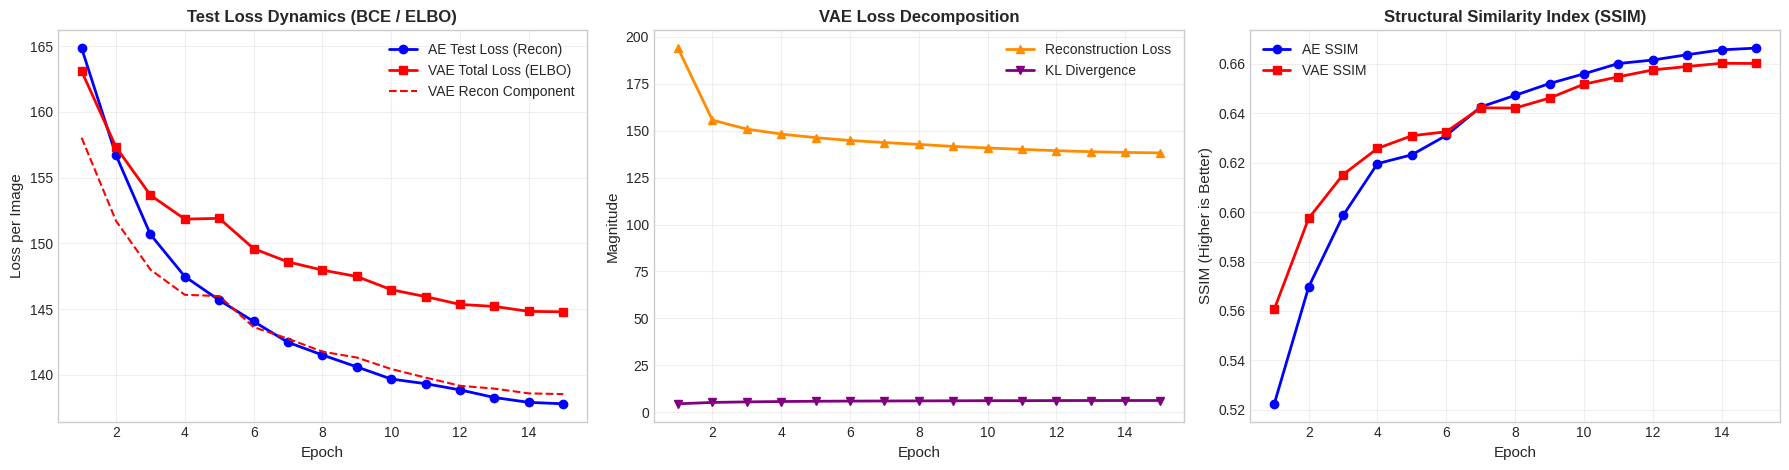

In [8]:
# ==============================================================================
# Cell 8: Convergence Trajectories & Loss Dynamics
# ==============================================================================
epochs_range = range(1, NUM_EPOCHS + 1)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# Subplot 1: Total Loss Progression
axes[0].plot(epochs_range, ae_history['test_loss'], 'b-o', label='AE Test Loss (Recon)', linewidth=2)
axes[0].plot(epochs_range, vae_history['test_loss'], 'r-s', label='VAE Total Loss (ELBO)', linewidth=2)
axes[0].plot(epochs_range, vae_history['test_recon'], 'r--', label='VAE Recon Component', linewidth=1.5)
axes[0].set_title("Test Loss Dynamics (BCE / ELBO)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Loss per Image", fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Subplot 2: VAE ELBO Decomposition (Trade-off)
axes[1].plot(epochs_range, vae_history['train_recon'], color='darkorange', marker='^', label='Reconstruction Loss', linewidth=2)
axes[1].plot(epochs_range, vae_history['train_kl'], color='purple', marker='v', label='KL Divergence', linewidth=2)
axes[1].set_title("VAE Loss Decomposition", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Magnitude", fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Subplot 3: Structural Similarity Index (SSIM) Trajectory
axes[2].plot(epochs_range, ae_history['test_ssim'], 'b-o', label='AE SSIM', linewidth=2)
axes[2].plot(epochs_range, vae_history['test_ssim'], 'r-s', label='VAE SSIM', linewidth=2)
axes[2].set_title("Structural Similarity Index (SSIM)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Epoch", fontsize=11)
axes[2].set_ylabel("SSIM (Higher is Better)", fontsize=11)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 🧪 Experiment 1: Image Reconstruction Quality & Residual Error Heatmaps
We evaluate both models on unseen test images across all digit classes. We inspect:
1. Reconstructed stroke fidelity and sharpness.
2. **Absolute difference heatmaps** ($|x - \hat{x}|$) highlighting exact pixel error regions.
3. Quantitative metrics: **MSE (Mean Squared Error)**, **PSNR (Peak Signal-to-Noise Ratio)**, and **SSIM (Structural Similarity Index)**.


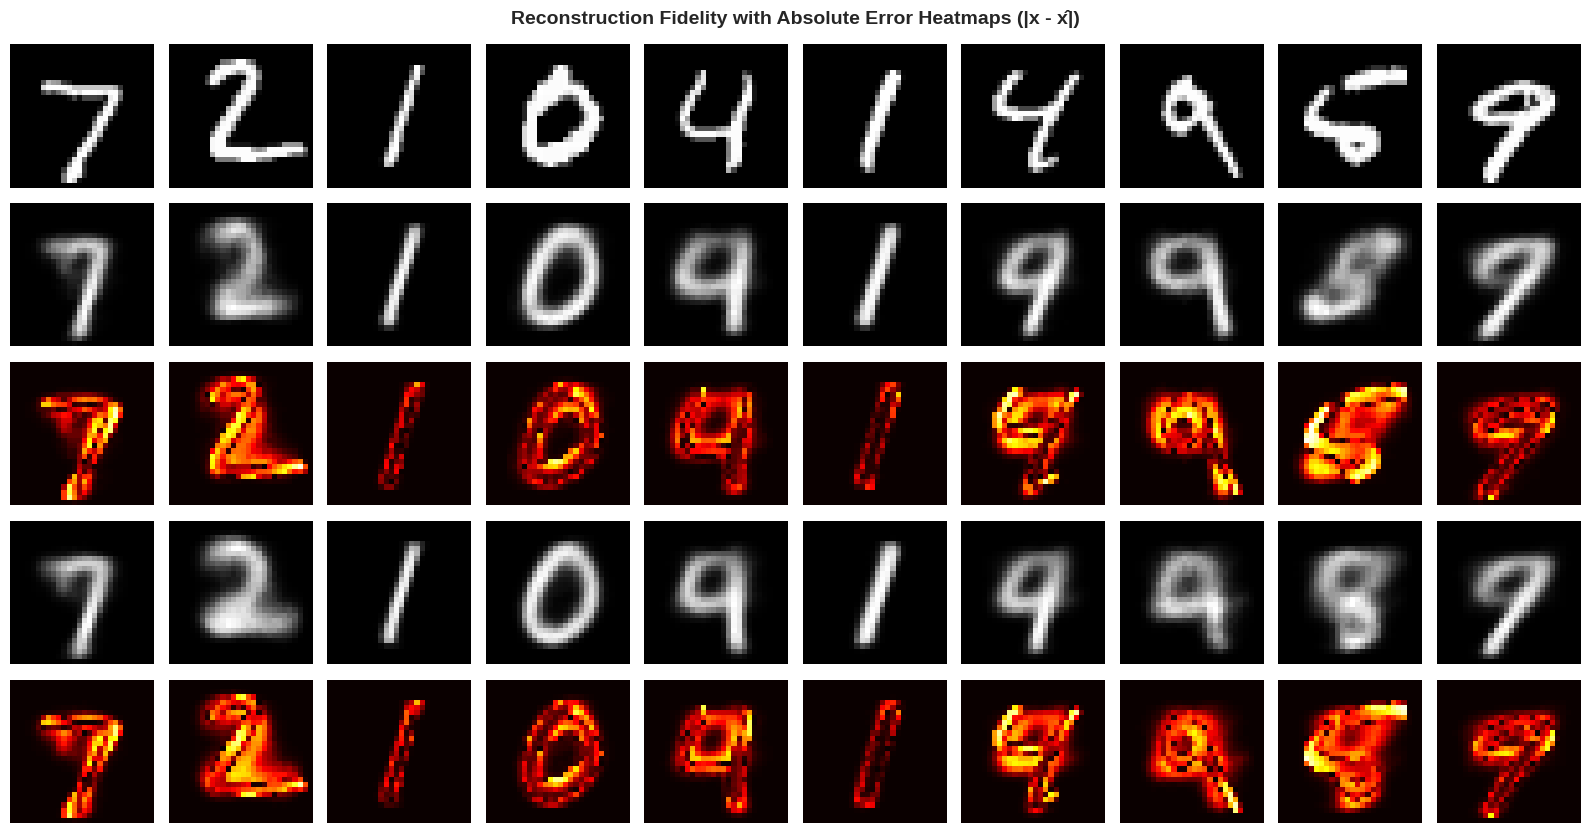


Model Architecture         | Test MSE (↓)   | Test PSNR (dB) (↑) | Test SSIM (↑) 
Deterministic Autoencoder  | 0.03804        | 14.21              | 0.6664        
Variational Autoencoder    | 0.03864        | 14.15              | 0.6602        


In [9]:
# ==============================================================================
# Cell 9: Qualitative and Quantitative Reconstruction Analysis
# ==============================================================================
ae_model.eval()
vae_model.eval()

# Retrieve fixed batch of unseen test samples
test_batch_imgs, test_batch_labels = next(iter(test_loader))
test_batch_imgs = test_batch_imgs.to(device)

with torch.no_grad():
    ae_recons, _ = ae_model(test_batch_imgs)
    vae_recons, _, _, _ = vae_model(test_batch_imgs)

orig_np = test_batch_imgs.cpu().numpy()
ae_np = ae_recons.cpu().numpy()
vae_np = vae_recons.cpu().numpy()

ae_residuals = np.abs(orig_np - ae_np)
vae_residuals = np.abs(orig_np - vae_np)

num_display = 10
fig, axes = plt.subplots(5, num_display, figsize=(16, 8.5))

for i in range(num_display):
    # Row 0: Original
    axes[0, i].imshow(orig_np[i, 0], cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_ylabel("Original", fontsize=11, fontweight='bold')

    # Row 1: AE Reconstruction
    axes[1, i].imshow(ae_np[i, 0], cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_ylabel("AE Recon", fontsize=11, fontweight='bold')

    # Row 2: AE Error Heatmap
    axes[2, i].imshow(ae_residuals[i, 0], cmap='hot', vmin=0, vmax=1)
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_ylabel("AE Residual", fontsize=11, fontweight='bold')

    # Row 3: VAE Reconstruction
    axes[3, i].imshow(vae_np[i, 0], cmap='gray')
    axes[3, i].axis('off')
    if i == 0: axes[3, i].set_ylabel("VAE Recon", fontsize=11, fontweight='bold')

    # Row 4: VAE Error Heatmap
    axes[4, i].imshow(vae_residuals[i, 0], cmap='hot', vmin=0, vmax=1)
    axes[4, i].axis('off')
    if i == 0: axes[4, i].set_ylabel("VAE Residual", fontsize=11, fontweight='bold')

fig.suptitle("Reconstruction Fidelity with Absolute Error Heatmaps (|x - x̂|)", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Quantitative Metrics Benchmark Table
print("\n" + "=" * 75)
print(f"{'Model Architecture':<26} | {'Test MSE (↓)':<14} | {'Test PSNR (dB) (↑)':<18} | {'Test SSIM (↑)':<14}")
print("=" * 75)
print(f"{'Deterministic Autoencoder':<26} | {ae_history['test_mse'][-1]:<14.5f} | {ae_history['test_psnr'][-1]:<18.2f} | {ae_history['test_ssim'][-1]:<14.4f}")
print(f"{'Variational Autoencoder':<26} | {vae_history['test_mse'][-1]:<14.5f} | {vae_history['test_psnr'][-1]:<18.2f} | {vae_history['test_ssim'][-1]:<14.4f}")
print("=" * 75)


---
## 🧪 Experiment 2: Image Generation via Random Prior Sampling
In generative modeling, generation is performed by sampling a latent vector from the prior distribution:
$$z \sim \mathcal{N}(0, I)$$
and decoding it into pixel space:
$$\hat{x}_{\text{gen}} = g_\phi(z)$$

### Theoretical Mechanics & Why AE Fails:
- **VAE**: The Kullback-Leibler divergence explicitly penalizes divergence between the aggregate posterior $\frac{1}{N}\sum q_\phi(z|x)$ and the standard normal prior $\mathcal{N}(0, I)$. Consequently, drawing random vectors from $\mathcal{N}(0, I)$ lands in densely populated, smoothly modeled regions where the decoder produces sharp, realistic digits.
- **AE**: The Autoencoder's latent space has **no statistical prior constraint**. The encoder maps inputs into arbitrary manifolds leaving huge unmapped "dead zones". Sampling from $\mathcal{N}(0, I)$ lands in these unmapped voids, forcing the decoder to extrapolate, which produces corrupted, blurry, or nonsensical shapes.


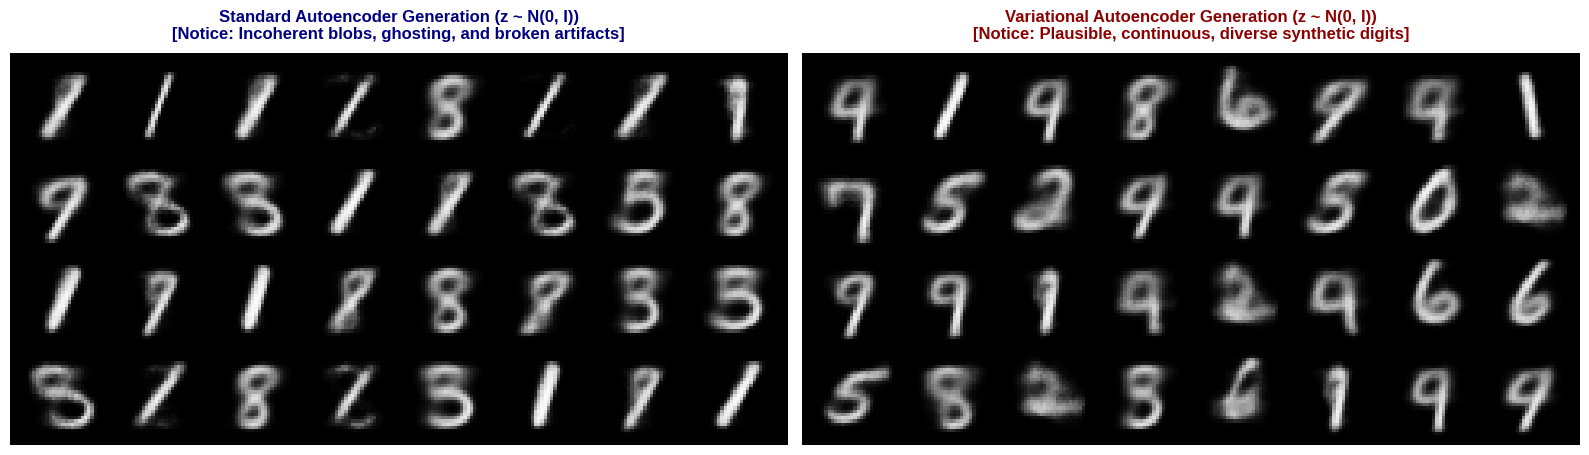

In [10]:
# ==============================================================================
# Cell 10: Image Generation via Random Prior Sampling (z ~ N(0, I))
# ==============================================================================
torch.manual_seed(101)  # Ensure identical latent coordinate queries for fair side-by-side comparison
num_samples = 32

# Sample identical latent points from N(0, I)
z_random = torch.randn(num_samples, LATENT_DIM).to(device)

ae_model.eval()
vae_model.eval()

with torch.no_grad():
    ae_generated = ae_model.decode(z_random).cpu()
    vae_generated = vae_model.decode(z_random).cpu()

grid_ae = make_grid(ae_generated, nrow=8, padding=2)
grid_vae = make_grid(vae_generated, nrow=8, padding=2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(grid_ae.permute(1, 2, 0).squeeze(), cmap='gray')
axes[0].set_title("Standard Autoencoder Generation (z ~ N(0, I))\n[Notice: Incoherent blobs, ghosting, and broken artifacts]",
                  fontsize=12, fontweight='bold', color='navy', pad=10)
axes[0].axis('off')

axes[1].imshow(grid_vae.permute(1, 2, 0).squeeze(), cmap='gray')
axes[1].set_title("Variational Autoencoder Generation (z ~ N(0, I))\n[Notice: Plausible, continuous, diverse synthetic digits]",
                  fontsize=12, fontweight='bold', color='darkred', pad=10)
axes[1].axis('off')

plt.tight_layout()
plt.show()


---
## 🧪 Experiment 3: Latent Space Geometry & Class Topology
We encode the complete test set ($N = 10,000$) into the 2D latent space and color each point by its true ground truth digit class (0–9).

### Architectural Differences Exposed:
1. **Autoencoder (Left)**:
   - Clusters are scattered with arbitrary scales and arbitrary distances from the origin.
   - Large empty regions ("dead zones") exist between digits.
   - Clusters can be irregular, elongated, or fragmented.
2. **VAE (Right)**:
   - The entire distribution is strictly centered at $(0, 0)$ with standard deviation $\approx 1$.
   - Clusters form a continuous, cohesive, circular Gaussian cloud without catastrophic voids.
   - Adjacent clusters naturally share semantically similar digit contours.


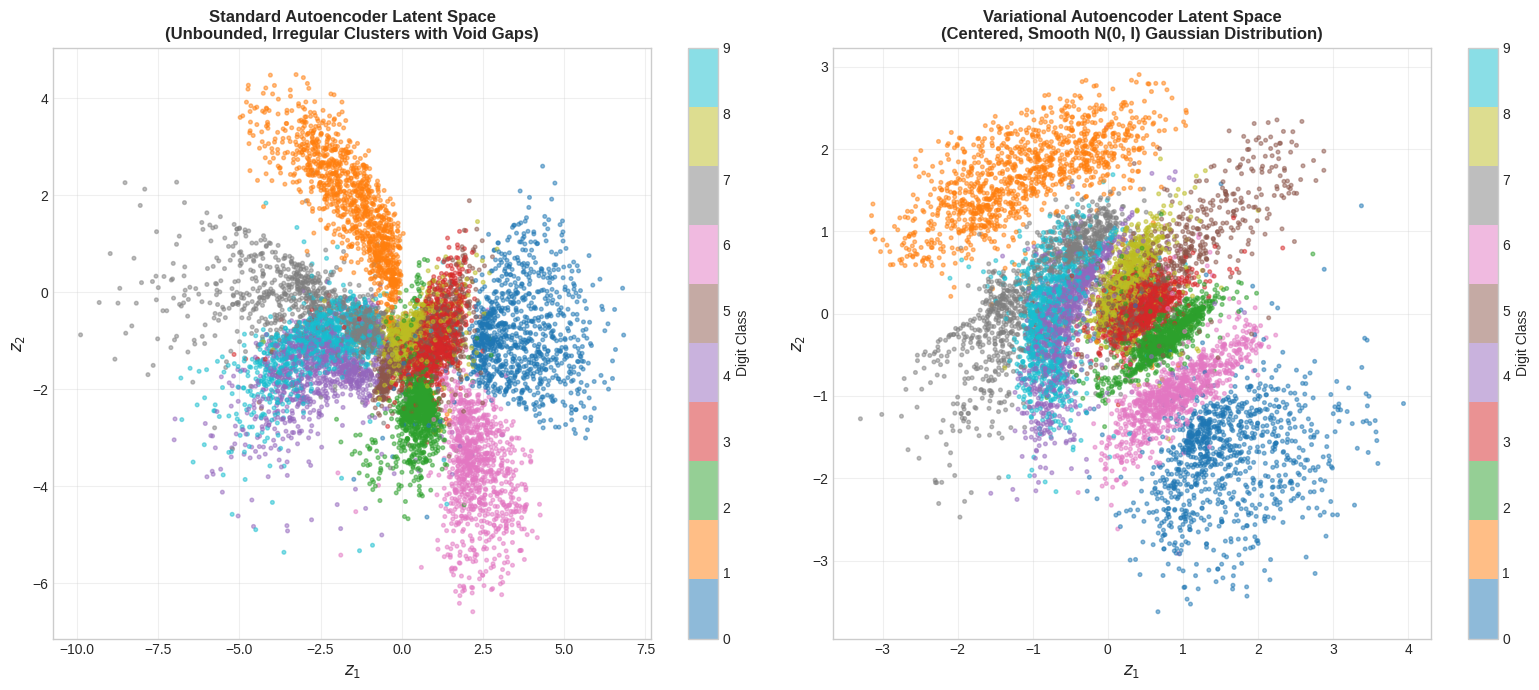

In [11]:
# ==============================================================================
# Cell 11: Latent Space Geometry & Class Clustering (10,000 Test Points)
# ==============================================================================
ae_latents, vae_latents, all_labels = [], [], []

ae_model.eval()
vae_model.eval()

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        z_ae = ae_model.encode(imgs)
        mu_vae, _ = vae_model.encode(imgs)

        ae_latents.append(z_ae.cpu().numpy())
        vae_latents.append(mu_vae.cpu().numpy())
        all_labels.append(labels.numpy())

ae_latents = np.concatenate(ae_latents, axis=0)
vae_latents = np.concatenate(vae_latents, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot Autoencoder 2D Latent Distribution
scatter_ae = axes[0].scatter(ae_latents[:, 0], ae_latents[:, 1], c=all_labels, cmap='tab10', alpha=0.5, s=7)
axes[0].set_title("Standard Autoencoder Latent Space\n(Unbounded, Irregular Clusters with Void Gaps)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("$z_1$", fontsize=12)
axes[0].set_ylabel("$z_2$", fontsize=12)
axes[0].grid(True, alpha=0.3)
fig.colorbar(scatter_ae, ax=axes[0], label='Digit Class', ticks=range(10))

# Plot VAE 2D Latent Distribution
scatter_vae = axes[1].scatter(vae_latents[:, 0], vae_latents[:, 1], c=all_labels, cmap='tab10', alpha=0.5, s=7)
axes[1].set_title("Variational Autoencoder Latent Space\n(Centered, Smooth N(0, I) Gaussian Distribution)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("$z_1$", fontsize=12)
axes[1].set_ylabel("$z_2$", fontsize=12)
axes[1].grid(True, alpha=0.3)
fig.colorbar(scatter_vae, ax=axes[1], label='Digit Class', ticks=range(10))

plt.tight_layout()
plt.show()


---
## 🧪 Experiment 4: 2D Generative Manifold Walk
Following the seminal work by Kingma & Welling (2013), we construct a dense 2D grid spanning $[-3, 3] \times [-3, 3]$ and decode every coordinate.
This reveals the full continuous generative manifold discovered by both models.


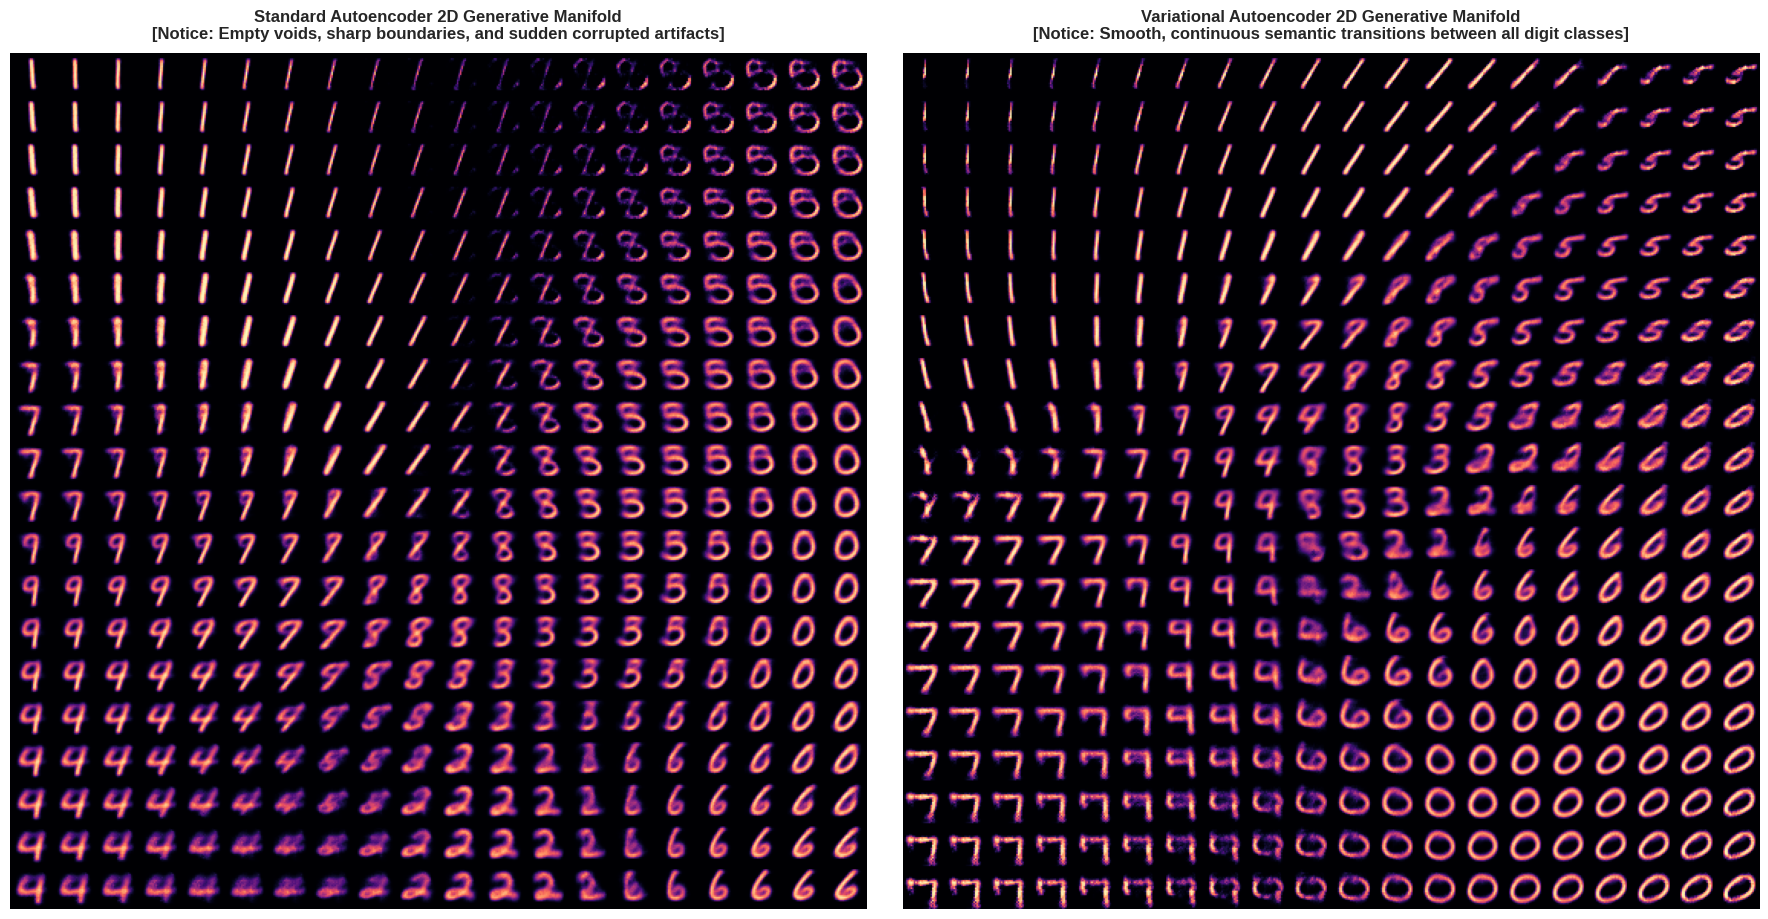

In [12]:
# ==============================================================================
# Cell 12: 2D Generative Manifold Walk (-3.0 to +3.0)
# ==============================================================================
grid_size = 20
grid_range = 3.0
grid_x = np.linspace(-grid_range, grid_range, grid_size)
grid_y = np.linspace(-grid_range, grid_range, grid_size)

canvas_ae = np.empty((28 * grid_size, 28 * grid_size))
canvas_vae = np.empty((28 * grid_size, 28 * grid_size))

ae_model.eval()
vae_model.eval()

with torch.no_grad():
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            decoded_ae = ae_model.decode(z).cpu().squeeze().numpy()
            decoded_vae = vae_model.decode(z).cpu().squeeze().numpy()

            canvas_ae[(grid_size - 1 - i) * 28:(grid_size - i) * 28, j * 28:(j + 1) * 28] = decoded_ae
            canvas_vae[(grid_size - 1 - i) * 28:(grid_size - i) * 28, j * 28:(j + 1) * 28] = decoded_vae

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

axes[0].imshow(canvas_ae, cmap='magma')
axes[0].set_title("Standard Autoencoder 2D Generative Manifold\n[Notice: Empty voids, sharp boundaries, and sudden corrupted artifacts]",
                  fontsize=12, fontweight='bold', pad=10)
axes[0].axis('off')

axes[1].imshow(canvas_vae, cmap='magma')
axes[1].set_title("Variational Autoencoder 2D Generative Manifold\n[Notice: Smooth, continuous semantic transitions between all digit classes]",
                  fontsize=12, fontweight='bold', pad=10)
axes[1].axis('off')

plt.tight_layout()
plt.show()


---
## 🧪 Experiment 5: Semantic Latent Space Interpolation (Morphing)
Given two arbitrary test images $x_A$ and $x_B$, we encode them into latent representations $z_A$ and $z_B$, and compute the linear interpolation trajectory:
$$z(\alpha) = (1 - \alpha)z_A + \alpha z_B, \quad \alpha \in [0, 1]$$
We decode $z(\alpha)$ across uniform steps to observe how the latent geometry traverses the data manifold.

- **AE**: Traverses through unpopulated regions between clusters, causing **abrupt discontinuous jumps** or **double-exposure ghosting**.
- **VAE**: Traverses through regularized Gaussian density, producing **smooth, continuous semantic morphing** where intermediate states resemble valid intermediate handwritten strokes.


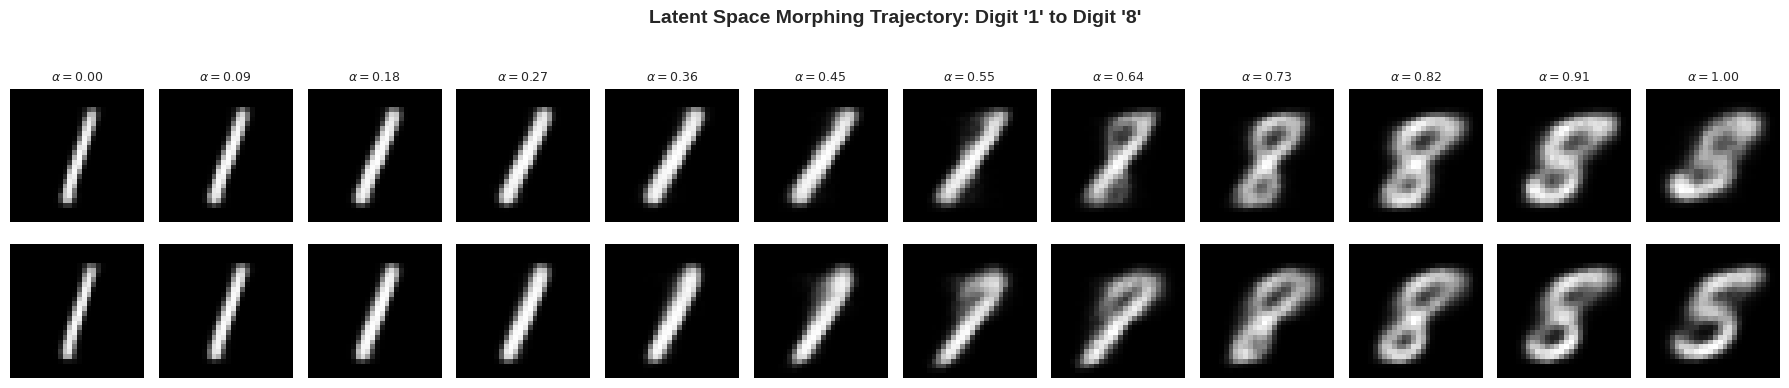

In [13]:
# ==============================================================================
# Cell 13: Latent Space Linear Interpolation (Digit A -> Digit B)
# ==============================================================================
def interpolate_digit_pair(model, img_a, img_b, is_vae=False, num_steps=12):
    model.eval()
    with torch.no_grad():
        if is_vae:
            z_a, _ = model.encode(img_a)
            z_b, _ = model.encode(img_b)
        else:
            z_a = model.encode(img_a)
            z_b = model.encode(img_b)

        alphas = np.linspace(0, 1, num_steps)
        interpolations = []

        for alpha in alphas:
            z_interp = (1.0 - alpha) * z_a + alpha * z_b
            decoded = model.decode(z_interp)
            interpolations.append(decoded.cpu().squeeze())

    return interpolations

# Select two distinct digits (e.g. Digit 1 and Digit 8)
img_1 = test_dataset[2][0].unsqueeze(0).to(device)  # Digit 1
img_8 = test_dataset[61][0].unsqueeze(0).to(device) # Digit 8

steps = 12
ae_morph = interpolate_digit_pair(ae_model, img_1, img_8, is_vae=False, num_steps=steps)
vae_morph = interpolate_digit_pair(vae_model, img_1, img_8, is_vae=True, num_steps=steps)

fig, axes = plt.subplots(2, steps, figsize=(18, 4))

for idx in range(steps):
    alpha = idx / (steps - 1)

    # AE Row
    axes[0, idx].imshow(ae_morph[idx], cmap='gray')
    axes[0, idx].axis('off')
    axes[0, idx].set_title(f"$\\alpha={alpha:.2f}$", fontsize=9)
    if idx == 0: axes[0, idx].set_ylabel("AE Morph", fontsize=11, fontweight='bold')

    # VAE Row
    axes[1, idx].imshow(vae_morph[idx], cmap='gray')
    axes[1, idx].axis('off')
    if idx == 0: axes[1, idx].set_ylabel("VAE Morph", fontsize=11, fontweight='bold')

fig.suptitle("Latent Space Morphing Trajectory: Digit '1' to Digit '8'", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
conclusion

| Dimension / Metric | Deterministic Autoencoder (AE) | Variational Autoencoder (VAE) |
| :--- | :--- | :--- |
| **Foundational Paradigm** | Deterministic function approximation ($x \to z \to \hat{x}$) | Directed Probabilistic Graphical Model ($q_\phi(z\|x)$ approximates $p(z)$) |
| **Latent Space Topology** | **Unconstrained & Discontinuous**. Scattered clusters with unpopulated dead zones. | **Smooth, Centered & Isotropic**. Gaussian prior $\mathcal{N}(0, I)$ regularization. |
| **Reconstruction Fidelity** | **Sharper (Lower MSE, Higher PSNR & SSIM)**. Latent points are fitted freely without penalty. | **Slightly blurrier**. Pays an **"information tax"** due to the KL divergence constraint. |
| **Generative Sampling ($z \sim \mathcal{N}(0, I)$)** | ❌ **Incoherent**. Samples land in unmapped voids, generating severe noise or blobs. | ✅ **High-fidelity**. Samples land within high-density regions of valid synthetic digits. |
| **Interpolation Trajectory** | Abrupt switches, double-exposure ghosting, non-manifold transitions. | Smooth, continuous semantic stroke evolution along the data manifold. |
| **Training Objective** | Empirical Reconstruction Loss $\mathcal{L}_{\text{recon}}$ | Negative ELBO: $\mathcal{L}_{\text{recon}} + \beta \cdot D_{\text{KL}}(q_\phi(z\|x) \parallel \mathcal{N}(0, I))$ |
| **Optimal Use Cases** | Deterministic compression, Denoising Autoencoders (DAE), Anomaly detection. | Unsupervised generative modeling, synthetic dataset expansion, representation disentanglement ($\beta$-VAE). |

---

### 🧠 Key Scientific Insights:
1. **The Regularization-Reconstruction Pareto Trade-off**:
   - The KL divergence term $D_{\text{KL}}(q_\phi(z|x) \parallel \mathcal{N}(0, I))$ acts as an informational bottleneck. It prevents the network from memorizing training points as infinitely sharp delta functions.
   - Tuning the $\beta$ parameter allows researchers to balance between sharper reconstructions ($\beta < 1$) and more disentangled/continuous generative manifolds ($\beta > 1$).
2. **Pathwise Differentiability via Reparameterization**:
   - Separating the stochasticity ($\epsilon \sim \mathcal{N}(0, I)$) from the variational parameters ($\mu, \sigma$) is the pivotal insight that made end-to-end backpropagation in latent variable models tractable.
3. **Architectural Selection Guide**:
   - If your application is **downstream classification, feature extraction, or deterministic denoising**, a standard or contractive Autoencoder is simpler and avoids reconstruction blurriness.
   - If your application requires **random sample generation, probabilistic latent exploration, or semantic morphing**, a Variational Autoencoder is mathematically and practically required.
